In [9]:
import math
import numpy as np
import scipy.stats as ss
import scipy.linalg as sl
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

SIR Model

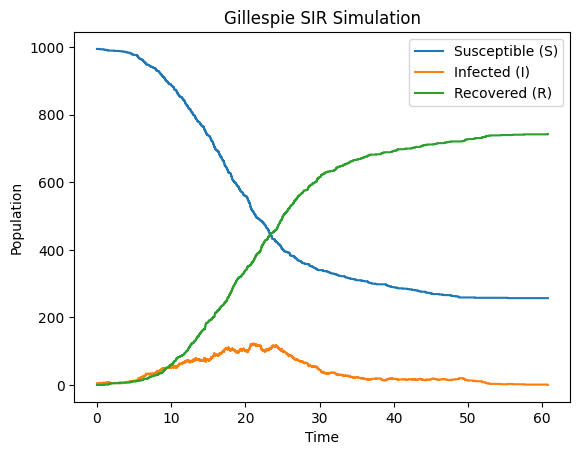

In [20]:
rng = np.random.default_rng(30)

def gillespie_SIR(s0, i0, r0, beta, gamma, t_tot, rng):
    """
    Gillespie simulation of the SIR model

    Inputs:
    s0 is the initial number of susceptible individuals
    i0 is the initial number of infected people
    r0 is the initial number of people who recovered
    beta is the infection rate
    gamma is the recovery rate
    t_tot is the duration of the simulation

    Outputs:
    T is the list of times
    S, I and R are the number of people in each compartments at each t
    """

    # Start at time t0
    s, i, r = s0, i0, r0
    t = 0
    T = [t]
    S = [s]
    I = [i]
    R = [r]
    n = s + i + r

    while t < t_tot and i > 0:

        a_infect = beta * s * i / n
        a_recover = gamma * i
        a = a_infect + a_recover

        t += -np.log(rng.random()) / a         # Time until the next event
        event = rng.random() * a               # Choose the event

        if event < a_infect:                   # Infection event
            if s > 0:
                s -= 1
                i += 1
        else:                                  # Recovery event
            if i > 0:
                i -= 1
                r += 1

        T.append(t)
        S.append(s)
        I.append(i)
        R.append(r)

    return T, S, R, I

s0 = 995
i0 = 5
r0 = 0
beta = 0.5          # infection rate
gamma = 0.3         # recovery rate
t_tot = 1000

T, S, R, I = gillespie_SIR(s0, i0, r0, beta, gamma, t_tot, rng)

plt.step(T, S, where='post', label='Susceptible (S)')
plt.step(T, I, where='post', label='Infected (I)')
plt.step(T, R, where='post', label='Recovered (R)')
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Gillespie SIR Simulation")
plt.legend()
plt.show()

In [35]:
s_init = 995
i0_init = 5
r0 = 0
beta = (0.3, 0.7)              # infection rates       beta=0.5
gamma = 0.6                    # recovery rate         gamma=0.3
mu = (0.01, 0.005)             # death rate
nu = (0.05, 0.01)              # vaccination rates
rho = (0.6, 0.6)               # evolution of the infection
eta = 0.01                     # susceptible again
t_tot = 10000

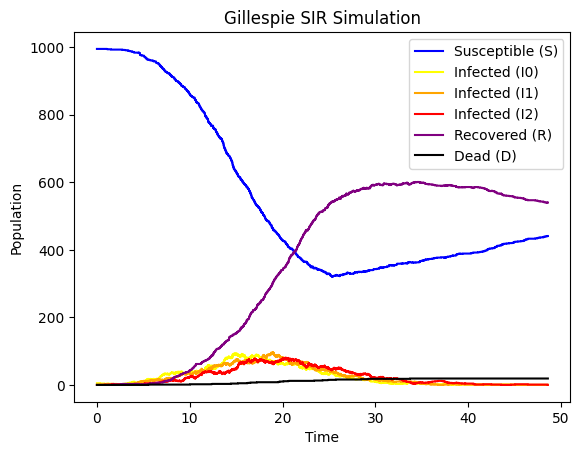

In [36]:
rng = np.random.default_rng(30)

def gillespie_no_vaccine(s_init, i0_init, beta, gamma, mu, rho, eta, t_tot, rng):
    """
    Gillespie simulation of the SIR model

    Inputs:
    s0 is the initial number of susceptible individuals
    i0 is the initial number of infected people
    r0 is the initial number of people who recovered
    beta is the infection rate
    gamma is the recovery rate
    t_tot is the duration of the simulation

    Outputs:
    T is the list of times
    S, I and R are the number of people in each compartments at each t
    """

    # Start at time t0
    s, i0, i1, i2, r, d = s_init, i0_init, 0, 0, 0, 0
    t = 0
    T = [t]
    S = [s]
    I0 = [i0]
    I1 = [i1]
    I2 = [i2]
    R = [r]
    D = [d]

    beta0, beta1 = beta
    mu1, mu2 = mu
    rho0, rho1 = rho

    while t < t_tot and (i0 + i1 + i2) > 0:

        n = s + i0 + i1 + i2 + r  # D excluded

        # Susceptible people can infected at rates...
        a_inf0 = beta0 * s * i0 / n
        a_inf1 = beta1 * s * i1 / n

        # Infected people can see their infection evolve at rates...
        a_prog0 = rho0 * i0
        a_prog1 = rho1 * i1

        # Infected people can die at rates...
        a_death1 = mu1 * i1
        a_death2 = mu2 * i2

        # Infected people can recover and thier immunity can evolve at rates...
        a_rec = gamma * i2

        # People who recovered can be susceptible again at rate...
        a_sus = eta * r

        rates = [a_inf0, a_inf1, a_prog0, a_prog1, a_death1, a_death2, a_rec, a_sus]

        # Total rate
        a0 = sum(rates)
        if a0 == 0:
            break

        # choose random time step
        tau = -np.log(rng.random()) / a0
        t += tau

        # choose the next event
        event = rng.random() * a0

        c = 0.0

        for j, rate in enumerate(rates):
            c += rate
            if event < c:
                break

        if j == 0:          # infection by I0
            s -= 1
            i0 += 1
        elif j == 1:        # infection by I1
            s -= 1
            i0 += 1
        elif j == 2:        # I0 -> I1
            i0 -= 1
            i1 += 1
        elif j == 3:        # I1 -> I2
            i1 -= 1
            i2 += 1
        elif j == 4:        # I1 -> D
            i1 -= 1
            d += 1
        elif j==5:          # I2 -> D
            i2 -= 1
            d += 1
        elif j==6:          # I2 -> R
            i2 -= 1
            r += 1
        elif j==7:          # R -> S
            r -= 1
            s += 1

        T.append(t)
        S.append(s)
        I0.append(i0)
        I1.append(i1)
        I2.append(i2)
        R.append(r)
        D.append(d)

    return T, S, I0, I1, I2, R, D

T, S, I0, I1, I2, R, D = gillespie_no_vaccine(s_init, i0_init, beta, gamma, mu, rho, eta, t_tot, rng)

plt.step(T, S, where='post', label='Susceptible (S)', color='blue')
plt.step(T, I0, where='post', label='Infected (I0)', color='yellow')
plt.step(T, I1, where='post', label='Infected (I1)', color='orange')
plt.step(T, I2, where='post', label='Infected (I2)', color='red')
plt.step(T, R, where='post', label='Recovered (R)', color='purple')
plt.step(T, D, where='post', label='Dead (D)', color='black')
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Gillespie SIR Simulation")
plt.legend()
plt.show()


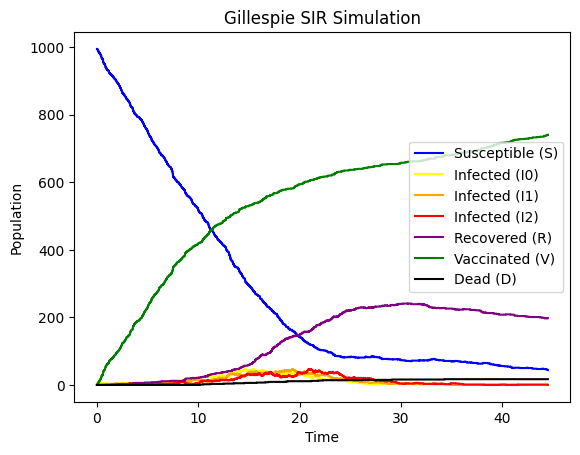

In [46]:
rng = np.random.default_rng(30)

def gillespie_vaccineS(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng):
    """
    Gillespie simulation of the SIR model

    Inputs:
    s0 is the initial number of susceptible individuals
    i0 is the initial number of infected people
    r0 is the initial number of people who recovered
    beta is the infection rate
    gamma is the recovery rate
    t_tot is the duration of the simulation

    Outputs:
    T is the list of times
    S, I and R are the number of people in each compartments at each t
    """

    # Start at time t0
    s, i0, i1, i2, r, d, v = s_init, i0_init, 0, 0, 0, 0, 0
    t = 0
    T = [t]
    S = [s]
    I0 = [i0]
    I1 = [i1]
    I2 = [i2]
    R = [r]
    V = [v]
    D = [d]

    beta0, beta1 = beta
    mu1, mu2 = mu
    rho0, rho1 = rho
    nu0, nu1 = nu

    while t < t_tot and (i0 + i1 + i2) > 0:

        n = s + i0 + i1 + i2 + r  # D excluded

        # Susceptible people can infected at rates...
        a_inf0 = beta0 * s * i0 / n
        a_inf1 = beta1 * s * i1 / n

        # Infected people can see their infection evolve at rates...
        a_prog0 = rho0 * i0
        a_prog1 = rho1 * i1

        # Infected people can die at rates...
        a_death1 = mu1 * i1
        a_death2 = mu2 * i2

        # Infected people can recover and thier immunity can evolve at rates...
        a_rec = gamma * i2

        # People who recovered can be susceptible again at rate...
        a_sus = eta * r

        # Susceptible and recovered people can be vaccinated at rates...
        # In the commented version, we consider that the more infected people with symptoms susceptible people know, the more they want to be vaccinated
        # a_vac0 = nu0 * s * (i1 + i2) / n
        a_vac0 = nu0 * s
        a_vac1 = nu1 * r

        rates = [a_inf0, a_inf1, a_prog0, a_prog1, a_death1, a_death2, a_rec, a_sus, a_vac0, a_vac1]

        # Total rate
        a0 = sum(rates)
        if a0 == 0:
            break

        # choose random time step
        tau = -np.log(rng.random()) / a0
        t += tau

        # choose the next event
        event = rng.random() * a0

        c = 0.0

        for j, rate in enumerate(rates):
            c += rate
            if event < c:
                break

        if j == 0:          # infection by I0
            s -= 1
            i0 += 1
        elif j == 1:        # infection by I1
            s -= 1
            i0 += 1
        elif j == 2:        # I0 -> I1
            i0 -= 1
            i1 += 1
        elif j == 3:        # I1 -> I2
            i1 -= 1
            i2 += 1
        elif j == 4:        # I1 -> D
            i1 -= 1
            d += 1
        elif j==5:          # I2 -> D
            i2 -= 1
            d += 1
        elif j==6:          # I2 -> R
            i2 -= 1
            r += 1
        elif j==7:          # R -> S
            r -= 1
            s += 1
        elif j==8:          # S -> V
            s -= 1
            v += 1
        elif j==9:          # R -> V
            r -= 1
            v += 1

        T.append(t)
        S.append(s)
        I0.append(i0)
        I1.append(i1)
        I2.append(i2)
        R.append(r)
        V.append(v)
        D.append(d)

    return T, S, I0, I1, I2, R, V, D

T, S, I0, I1, I2, R, V, D = gillespie_vaccineS(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng)

plt.step(T, S, where='post', label='Susceptible (S)', color='blue')
plt.step(T, I0, where='post', label='Infected (I0)', color='yellow')
plt.step(T, I1, where='post', label='Infected (I1)', color='orange')
plt.step(T, I2, where='post', label='Infected (I2)', color='red')
plt.step(T, R, where='post', label='Recovered (R)', color='purple')
plt.step(T, V, where='post', label='Vaccinated (V)', color='green')
plt.step(T, D, where='post', label='Dead (D)', color='black')
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Gillespie SIR Simulation")
plt.legend()
plt.show()


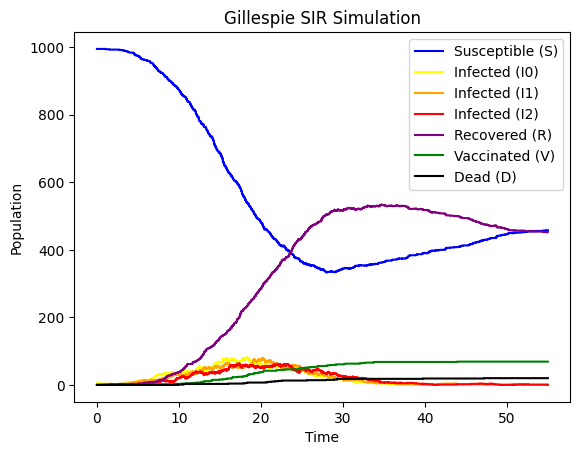

In [47]:
rng = np.random.default_rng(30)

def gillespie_vaccineI(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng):
    """
    Gillespie simulation of the SIR model

    Inputs:
    s0 is the initial number of susceptible individuals
    i0 is the initial number of infected people
    r0 is the initial number of people who recovered
    beta is the infection rate
    gamma is the recovery rate
    t_tot is the duration of the simulation

    Outputs:
    T is the list of times
    S, I and R are the number of people in each compartments at each t
    """

    # Start at time t0
    s, i0, i1, i2, r, d, v = s_init, i0_init, 0, 0, 0, 0, 0
    t = 0
    T = [t]
    S = [s]
    I0 = [i0]
    I1 = [i1]
    I2 = [i2]
    R = [r]
    V = [v]
    D = [d]

    beta0, beta1 = beta
    mu1, mu2 = mu
    rho0, rho1 = rho
    nu1, nu2 = nu

    while t < t_tot and (i0 + i1 + i2) > 0:

        n = s + i0 + i1 + i2 + r  # D excluded

        # Susceptible people can infected at rates...
        a_inf0 = beta0 * s * i0 / n
        a_inf1 = beta1 * s * i1 / n

        # Infected people can see their infection evolve at rates...
        a_prog0 = rho0 * i0
        a_prog1 = rho1 * i1

        # Infected people can die at rates...
        a_death1 = mu1 * i1
        a_death2 = mu2 * i2

        # Infected people can recover and thier immunity can evolve at rates...
        a_rec = gamma * i2

        # People who recovered can be susceptible again at rate...
        a_sus = eta * r

        # Infected people with symptoms can be vaccinated at rates...
        a_vac1 = nu1 * i1
        a_vac2 = nu2 * i2

        rates = [a_inf0, a_inf1, a_prog0, a_prog1, a_death1, a_death2, a_rec, a_sus, a_vac1, a_vac2]

        # Total rate
        a0 = sum(rates)
        if a0 == 0:
            break

        # choose random time step
        tau = -np.log(rng.random()) / a0
        t += tau

        # choose the next event
        event = rng.random() * a0

        c = 0.0

        for j, rate in enumerate(rates):
            c += rate
            if event < c:
                break

        if j == 0:          # infection by I0
            s -= 1
            i0 += 1
        elif j == 1:        # infection by I1
            s -= 1
            i0 += 1
        elif j == 2:        # I0 -> I1
            i0 -= 1
            i1 += 1
        elif j == 3:        # I1 -> I2
            i1 -= 1
            i2 += 1
        elif j == 4:        # I1 -> D
            i1 -= 1
            d += 1
        elif j==5:          # I2 -> D
            i2 -= 1
            d += 1
        elif j==6:          # I2 -> R
            i2 -= 1
            r += 1
        elif j==7:          # R -> S
            r -= 1
            s += 1
        elif j==8:          # I1 -> V
            i1 -= 1
            v += 1
        elif j==9:          # I2 -> V
            i2 -= 1
            v += 1

        T.append(t)
        S.append(s)
        I0.append(i0)
        I1.append(i1)
        I2.append(i2)
        R.append(r)
        V.append(v)
        D.append(d)

    return T, S, I0, I1, I2, R, V, D

T, S, I0, I1, I2, R, V, D = gillespie_vaccineI(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng)

plt.step(T, S, where='post', label='Susceptible (S)', color='blue')
plt.step(T, I0, where='post', label='Infected (I0)', color='yellow')
plt.step(T, I1, where='post', label='Infected (I1)', color='orange')
plt.step(T, I2, where='post', label='Infected (I2)', color='red')
plt.step(T, R, where='post', label='Recovered (R)', color='purple')
plt.step(T, V, where='post', label='Vaccinated (V)', color='green')
plt.step(T, D, where='post', label='Dead (D)', color='black')
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Gillespie SIR Simulation")
plt.legend()
plt.show()


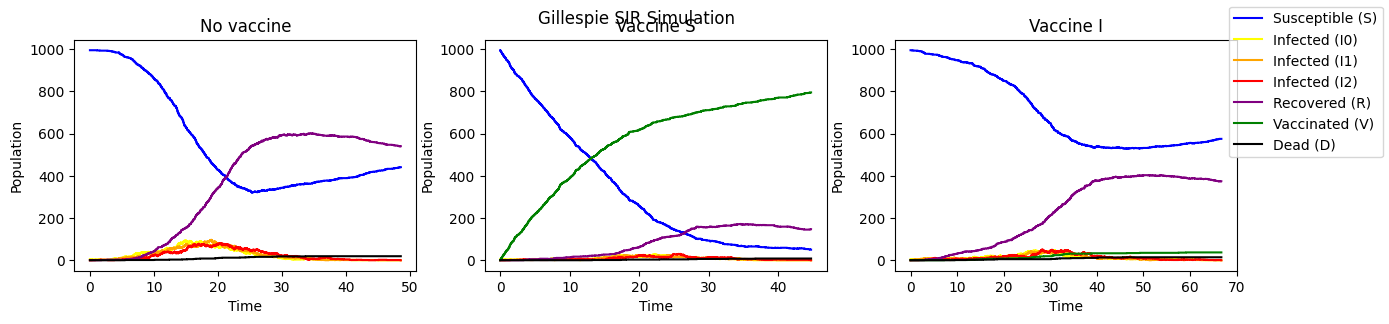

In [48]:
rng = np.random.default_rng(30)

T_no, S_no, I0_no, I1_no, I2_no, R_no, D_no = gillespie_no_vaccine(s_init, i0_init, beta, gamma, mu, rho, eta, t_tot, rng)
T_vacS, S_vacS, I0_vacS, I1_vacS, I2_vacS, R_vacS, V_vacS, D_vacS = gillespie_vaccineS(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng)
T_vacI, S_vacI, I0_vacI, I1_vacI, I2_vacI, R_vacI, V_vacI, D_vacI = gillespie_vaccineI(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng)

fig, axs = plt.subplots(1,3)

axs[0].step(T_no, S_no, where='post', color='blue')
axs[0].step(T_no, I0_no, where='post', color='yellow')
axs[0].step(T_no, I1_no, where='post', color='orange')
axs[0].step(T_no, I2_no, where='post', color='red')
axs[0].step(T_no, R_no, where='post', color='purple')
axs[0].step(T_no, D_no, where='post', color='black')
axs[0].set_title("No vaccine")

axs[1].step(T_vacS, S_vacS, where='post', color='blue')
axs[1].step(T_vacS, I0_vacS, where='post', color='yellow')
axs[1].step(T_vacS, I1_vacS, where='post', color='orange')
axs[1].step(T_vacS, I2_vacS, where='post', color='red')
axs[1].step(T_vacS, R_vacS, where='post', color='purple')
axs[1].step(T_vacS, V_vacS, where='post', color='green')
axs[1].step(T_vacS, D_vacS, where='post', color='black')
axs[1].set_title("Vaccine S")

axs[2].step(T_vacI, S_vacI, where='post', label='Susceptible (S)', color='blue')
axs[2].step(T_vacI, I0_vacI, where='post', label='Infected (I0)', color='yellow')
axs[2].step(T_vacI, I1_vacI, where='post', label='Infected (I1)', color='orange')
axs[2].step(T_vacI, I2_vacI, where='post', label='Infected (I2)', color='red')
axs[2].step(T_vacI, R_vacI, where='post', label='Recovered (R)', color='purple')
axs[2].step(T_vacI, V_vacI, where='post', label='Vaccinated (V)', color='green')
axs[2].step(T_vacI, D_vacI, where='post', label='Dead (D)', color='black')
axs[2].set_title("Vaccine I")

for ax in axs.flat:
    ax.set(xlabel='Time', ylabel='Population')

fig.set_figheight(3)
fig.set_figwidth(15)
fig.suptitle("Gillespie SIR Simulation")
fig.legend()
plt.show()


In [49]:
rng = np.random.default_rng(30)

n_sim = 100

deaths_no_vac = []
deaths_vacS = []
deaths_vacI = []

for k in range(n_sim):
    rng = np.random.default_rng(k)

    T,S,I0,I1,I2,R,D = gillespie_no_vaccine(s_init, i0_init, beta, gamma, mu, rho, eta, t_tot, rng)
    deaths_no_vac.append(D[-1])
    # max_infected_no_vac = 

    T,S,I0,I1,I2,R,V,D = gillespie_vaccineS(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng)
    deaths_vacS.append(D[-1])
    # max_infected_vacS =

    T,S,I0,I1,I2,R,V,D = gillespie_vaccineI(s_init, i0_init, beta, gamma, mu, nu, rho, eta, t_tot, rng)
    deaths_vacI.append(D[-1])
    # max_infected_vacI =

res = ss.bootstrap((np.array(deaths_no_vac),), np.mean, confidence_level=0.95)
print(res.confidence_interval)

res = ss.bootstrap((np.array(deaths_vacS),), np.mean, confidence_level=0.95)
print(res.confidence_interval)

res = ss.bootstrap((np.array(deaths_vacI),), np.mean, confidence_level=0.95)
print(res.confidence_interval)

ConfidenceInterval(low=np.float64(15.19), high=np.float64(17.55))
ConfidenceInterval(low=np.float64(7.13), high=np.float64(8.49))
ConfidenceInterval(low=np.float64(14.93), high=np.float64(16.7))
